In [1]:
import os, string, shapely, itertools

import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import shapely.ops as so

from matplotlib.ticker import MultipleLocator
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.transforms import ScaledTranslation
from shapely.ops import cascaded_union
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.lines import Line2D
from shapely.validation import make_valid

import scipy.interpolate as inter

plt.rcParams['legend.handlelength'] = 1
plt.rcParams['legend.handleheight'] = 1.125
plt.rcParams["font.family"]         = "Avenir"

path_to_images = '/Users/Guille/Desktop/india_power/images'
path_to_csvs   = '/Users/Guille/Desktop/india_power/gridpath_india_viz/csvs'
path_to_input  = '/Users/Guille/Desktop/india_power/input_data/'
path_to_load   = '/Users/Guille/Desktop/india_power/input_data/load'
path_to_data   = '/Users/Guille/Desktop/india_power/gridpath_india_viz/data'
path_to_tables = '/Users/Guille/Desktop/india_power/tables'

In [2]:
df_ = pd.read_csv(path_to_input + 'generators/existing_generators_2025.csv')
df_ = df_.loc[df_['type'] == 'coal'].reset_index(drop = True)
df_ = df_[['load_zone', 'region', 'fixed_cost_Rs_kw', 'vom_inr_per_mwh']]
df_ = df_.groupby(['region']).agg({'fixed_cost_Rs_kw': 'mean', 
                                   'vom_inr_per_mwh': 'mean'}).reset_index(drop = False)
print(df_)

  region  fixed_cost_Rs_kw  vom_inr_per_mwh
0     ER       7429.739391      2394.182095
1    NER      19683.200000      5880.000000
2     NR       7510.764175      2870.501182
3     SR       5818.473790      2850.135328
4     WR       7761.533469      2386.617350


In [3]:
# New projects costs and operational characteristics
new_projects_excel            = path_to_input + "new_projects_v41.xlsx"
new_battery_costs_all         = pd.read_excel(new_projects_excel, sheet_name = "adapted_new_battery_costs_2050")
new_hydrogen_cavern_costs_all = pd.read_excel(new_projects_excel, sheet_name = "new_hydrogen_cavern_costs_2050")
new_hydrogen_tank_costs_all   = pd.read_excel(new_projects_excel, sheet_name = "new_hydrogen_tank_costs_2050")
new_solar_costs_all           = pd.read_excel(new_projects_excel, sheet_name = "adapted_new_solar_costs_2050")
new_wind_costs_all            = pd.read_excel(new_projects_excel, sheet_name = "adapted_new_wind_costs_2050")
new_conventional_costs_all    = pd.read_excel(new_projects_excel, sheet_name = "new_conventional_costs_2050")
new_nuclear_costs_all         = pd.read_excel(new_projects_excel, sheet_name = "new_nuclear_costs_2050")
new_hydro_costs_all           = pd.read_excel(new_projects_excel, sheet_name = "new_hydro_pumped_costs_2050")

# Exchange Rate
USD_to_INR = 72

In [28]:
path_to_pier_cost = '/Users/Guille/Desktop/india_power/data/technology_costs/PIER2_supply_costs.xlsx'

cost_pier_ = pd.read_excel(path_to_pier_cost, 
                           sheet_name = "new_capacity", 
                           index_col = 0)
print(cost_pier_)

                        2024          2025          2026          2027  \
Technology                                                               
EG_BIOMASS       7713.457240   7713.457240   7713.457240   7713.457240   
EG_CCGT          8512.227803   8512.227803   8512.227803   8512.227803   
EG_COAL         13721.031293  13721.031293  13721.031293  13721.031293   
EG_LH            8837.164588   8837.164588   8837.164588   8837.164588   
EG_OCGT          6679.750649   6679.750649   6679.750649   6679.750649   
EG_PHWR         20833.210348  20833.210348  20833.210348  20833.210348   
EG_SH           11825.348755  11825.348755  11825.348755  11825.348755   
EG_SMR          35289.429392  35289.429392  35289.429392  35289.429392   
EG_SOLARGM       5439.705856   5254.925032   5076.421009   4903.980572   
EG_SOLARRF       5525.865799   5346.325035   5172.617725   5004.554334   
EG_WINDOFF      34540.361674  32741.428192  31036.186886  29419.758075   
EG_WINDON        9509.791081   9445.20

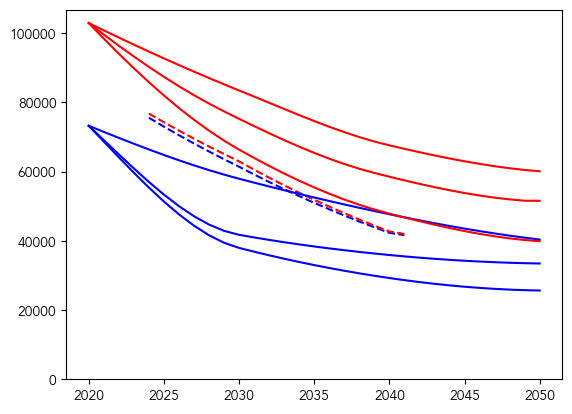

In [31]:
plt.figure()

plt.plot(cost_pier_.loc['EG_SOLARGM']*1000/72, ls = '--', c = 'b')
plt.plot(cost_pier_.loc['EG_SOLARRF']*1000/72, ls = '--', c = 'r')

idx_ = ((new_solar_costs_all['technology'] == 'SolarPV_tilt') 
        & (new_solar_costs_all['scenario'] == 'PVlow'))

plt.plot(new_solar_costs_all.loc[idx_, 'vintage'], 
         new_solar_costs_all.loc[idx_, 'annualized_real_cost_per_mw_yr'], 
         ls = '-', c = 'b')

idx_ = ((new_solar_costs_all['technology'] == 'SolarPV_tilt') 
        & (new_solar_costs_all['scenario'] == 'PVmid'))

plt.plot(new_solar_costs_all.loc[idx_, 'vintage'], 
         new_solar_costs_all.loc[idx_, 'annualized_real_cost_per_mw_yr'], 
         ls = '-', c = 'b')

idx_ = ((new_solar_costs_all['technology'] == 'SolarPV_tilt') 
        & (new_solar_costs_all['scenario'] == 'PVhigh'))

plt.plot(new_solar_costs_all.loc[idx_, 'vintage'], 
         new_solar_costs_all.loc[idx_, 'annualized_real_cost_per_mw_yr'], 
         ls = '-', c = 'b')

idx_ = ((new_solar_costs_all['technology'] == 'SolarPV_roof') 
        & (new_solar_costs_all['scenario'] == 'PVlow'))

plt.plot(new_solar_costs_all.loc[idx_, 'vintage'], 
         new_solar_costs_all.loc[idx_, 'annualized_real_cost_per_mw_yr'], 
         ls = '-', c = 'r')

idx_ = ((new_solar_costs_all['technology'] == 'SolarPV_roof') 
        & (new_solar_costs_all['scenario'] == 'PVmid'))

plt.plot(new_solar_costs_all.loc[idx_, 'vintage'], 
         new_solar_costs_all.loc[idx_, 'annualized_real_cost_per_mw_yr'], 
         ls = '-', c = 'r')

idx_ = ((new_solar_costs_all['technology'] == 'SolarPV_roof') 
        & (new_solar_costs_all['scenario'] == 'PVhigh'))

plt.plot(new_solar_costs_all.loc[idx_, 'vintage'], 
         new_solar_costs_all.loc[idx_, 'annualized_real_cost_per_mw_yr'], 
         ls = '-', c = 'r')

plt.ylim(0,)
plt.show()

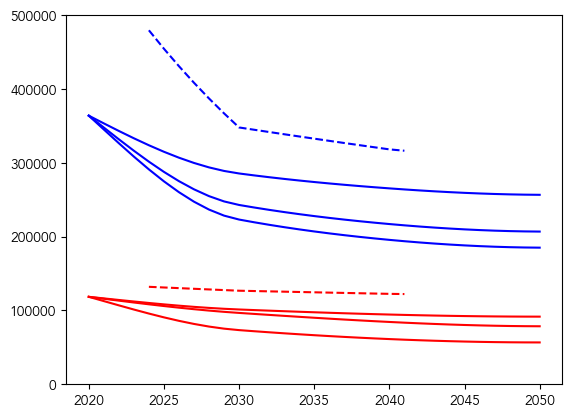

In [32]:
plt.figure()

plt.plot(cost_pier_.loc['EG_WINDON']*1000/72, ls = '--', c = 'r')
plt.plot(cost_pier_.loc['EG_WINDOFF']*1000/72, ls = '--', c = 'b')

idx_ = ((new_wind_costs_all['technology'] == 'Wind') 
        & (new_wind_costs_all['scenario'] == 'WDlow'))

plt.plot(new_wind_costs_all.loc[idx_, 'vintage'], 
         new_wind_costs_all.loc[idx_, 'annualized_real_cost_per_mw_yr'], 
         ls = '-', 
         c = 'r')

idx_ = ((new_wind_costs_all['technology'] == 'Wind') 
        & (new_wind_costs_all['scenario'] == 'WDmid'))

plt.plot(new_wind_costs_all.loc[idx_, 'vintage'], 
         new_wind_costs_all.loc[idx_, 'annualized_real_cost_per_mw_yr'], 
         ls = '-', 
         c = 'r')

idx_ = ((new_wind_costs_all['technology'] == 'Wind') 
        & (new_wind_costs_all['scenario'] == 'WDhigh'))

plt.plot(new_wind_costs_all.loc[idx_, 'vintage'], 
         new_wind_costs_all.loc[idx_, 'annualized_real_cost_per_mw_yr'], 
         ls = '-', 
         c = 'r')

idx_ = ((new_wind_costs_all['technology'] == 'Offshore') 
        & (new_wind_costs_all['scenario'] == 'WDlow'))

plt.plot(new_wind_costs_all.loc[idx_, 'vintage'], 
         new_wind_costs_all.loc[idx_, 'annualized_real_cost_per_mw_yr'], 
         ls = '-', 
         c = 'b')

idx_ = ((new_wind_costs_all['technology'] == 'Offshore') 
        & (new_wind_costs_all['scenario'] == 'WDmid'))

plt.plot(new_wind_costs_all.loc[idx_, 'vintage'], 
         new_wind_costs_all.loc[idx_, 'annualized_real_cost_per_mw_yr'], 
         ls = '-', 
         c = 'b')

idx_ = ((new_wind_costs_all['technology'] == 'Offshore') 
        & (new_wind_costs_all['scenario'] == 'WDhigh'))

plt.plot(new_wind_costs_all.loc[idx_, 'vintage'], 
         new_wind_costs_all.loc[idx_, 'annualized_real_cost_per_mw_yr'], 
         ls = '-', 
         c = 'b')

plt.ylim(0,)
plt.show()

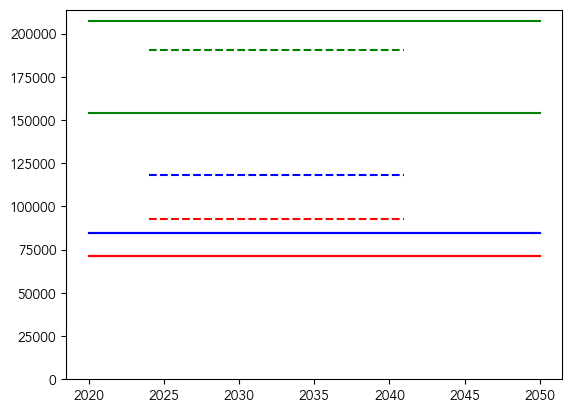

In [35]:
plt.figure()

plt.plot(cost_pier_.loc['EG_OCGT']*1000/72, ls = '--', c = 'r')
plt.plot(cost_pier_.loc['EG_CCGT']*1000/72, ls = '--', c = 'b')
plt.plot(cost_pier_.loc['EG_COAL']*1000/72, ls = '--', c = 'g')

idx_ = ((new_conventional_costs_all['technology'] == 'Supercritical_Coal') 
        & (new_conventional_costs_all['scenario'] == 'CONVlow'))

plt.plot(new_conventional_costs_all.loc[idx_, 'vintage'], 
         new_conventional_costs_all.loc[idx_, 'annualized_real_cost_per_mw_yr'], 
         ls = '-', 
         c = 'g')

idx_ = ((new_conventional_costs_all['technology'] == 'Supercritical_Coal') 
        & (new_conventional_costs_all['scenario'] == 'CONVmid'))

plt.plot(new_conventional_costs_all.loc[idx_, 'vintage'], 
         new_conventional_costs_all.loc[idx_, 'annualized_real_cost_per_mw_yr'], 
         ls = '-', 
         c = 'g')

idx_ = ((new_conventional_costs_all['technology'] == 'Supercritical_Coal') 
        & (new_conventional_costs_all['scenario'] == 'CONVhigh'))

plt.plot(new_conventional_costs_all.loc[idx_, 'vintage'], 
         new_conventional_costs_all.loc[idx_, 'annualized_real_cost_per_mw_yr'], 
         ls = '-', 
         c = 'g')

idx_ = ((new_conventional_costs_all['technology'] == 'CCGT') 
        & (new_conventional_costs_all['scenario'] == 'CONVlow'))

plt.plot(new_conventional_costs_all.loc[idx_, 'vintage'], 
         new_conventional_costs_all.loc[idx_, 'annualized_real_cost_per_mw_yr'], 
         ls = '-', 
         c = 'b')

idx_ = ((new_conventional_costs_all['technology'] == 'CCGT') 
        & (new_conventional_costs_all['scenario'] == 'CONVmid'))

plt.plot(new_conventional_costs_all.loc[idx_, 'vintage'], 
         new_conventional_costs_all.loc[idx_, 'annualized_real_cost_per_mw_yr'], 
         ls = '-', 
         c = 'b')

idx_ = ((new_conventional_costs_all['technology'] == 'CCGT') 
        & (new_conventional_costs_all['scenario'] == 'CONVhigh'))

plt.plot(new_conventional_costs_all.loc[idx_, 'vintage'], 
         new_conventional_costs_all.loc[idx_, 'annualized_real_cost_per_mw_yr'], 
         ls = '-', 
         c = 'b')

idx_ = ((new_conventional_costs_all['technology'] == 'CT') 
        & (new_conventional_costs_all['scenario'] == 'CONVlow'))

plt.plot(new_conventional_costs_all.loc[idx_, 'vintage'], 
         new_conventional_costs_all.loc[idx_, 'annualized_real_cost_per_mw_yr'], 
         ls = '-', 
         c = 'r')

idx_ = ((new_conventional_costs_all['technology'] == 'CT') 
        & (new_conventional_costs_all['scenario'] == 'CONVmid'))

plt.plot(new_conventional_costs_all.loc[idx_, 'vintage'], 
         new_conventional_costs_all.loc[idx_, 'annualized_real_cost_per_mw_yr'], 
         ls = '-', 
         c = 'r')

idx_ = ((new_conventional_costs_all['technology'] == 'CT') 
        & (new_conventional_costs_all['scenario'] == 'CONVhigh'))

plt.plot(new_conventional_costs_all.loc[idx_, 'vintage'], 
         new_conventional_costs_all.loc[idx_, 'annualized_real_cost_per_mw_yr'], 
         ls = '-', 
         c = 'r')

plt.ylim(0,)
plt.show()

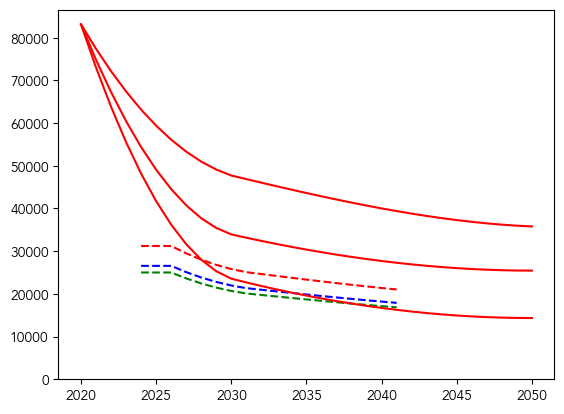

In [47]:
plt.figure()

plt.plot(cost_pier_.loc['TWOHR_BATTERY']*1000/72, ls = '--', c = 'r')
plt.plot(cost_pier_.loc['FOURHR_BATTERY']*1000/72, ls = '--', c = 'b')
plt.plot(cost_pier_.loc['SIXHR_BATTERY']*1000/72, ls = '--', c = 'g')

idx_ = ((new_battery_costs_all['technology'] == 'Battery') 
        & (new_battery_costs_all['scenario'] == 'STlow'))

plt.plot(new_battery_costs_all.loc[idx_, 'vintage'], 
         (new_battery_costs_all.loc[idx_, 'annualized_real_cost_per_mw_yr']
         + new_battery_costs_all.loc[idx_, 'annualized_real_cost_per_mwh_yr']), 
         ls = '-', 
         c = 'r')

idx_ = ((new_battery_costs_all['technology'] == 'Battery') 
        & (new_battery_costs_all['scenario'] == 'STmid'))

plt.plot(new_battery_costs_all.loc[idx_, 'vintage'], 
         (new_battery_costs_all.loc[idx_, 'annualized_real_cost_per_mw_yr']
         + new_battery_costs_all.loc[idx_, 'annualized_real_cost_per_mwh_yr']), 
         ls = '-', 
         c = 'r')

idx_ = ((new_battery_costs_all['technology'] == 'Battery') 
        & (new_battery_costs_all['scenario'] == 'SThigh'))

plt.plot(new_battery_costs_all.loc[idx_, 'vintage'], 
         (new_battery_costs_all.loc[idx_, 'annualized_real_cost_per_mw_yr']
         + new_battery_costs_all.loc[idx_, 'annualized_real_cost_per_mwh_yr']), 
         ls = '-', 
         c = 'r')

plt.ylim(0,)
plt.show()

In [116]:
path_to_input      = '/Users/Guille/Desktop/india_power/input_data/'
path_to_scenarios  = '/Users/Guille/Desktop/india_power/scenarios/'

scenario = 'cost/VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid/'

lzs_ = pd.read_csv(path_to_input + 'load_zones.csv')[['load_zone', 'region']]

df_ = pd.read_csv(path_to_scenarios + scenario + 'results/project_timepoint.csv', low_memory = False)

df_['capacity_availability'] = df_['availability_derate'] * df_['capacity_mw'] * df_['timepoint_weight']
df_['power_mw'] = df_['power_mw'] * df_['timepoint_weight']

df_ = pd.merge(df_, lzs_, on = 'load_zone', how = 'right')

df_ = df_[['period', 
           'project', 
           'timepoint', 
           'timepoint_weight',
           'region',  
           'technology', 
           'capacity_mw', 
           'capacity_availability',
           'power_mw']]

# 1. Convert to datetime
df_["dt"] = pd.to_datetime(df_["timepoint"] - 1, format="%Y%m%d%H")

# 2. Extract year, month, day, hour
df_["year"]  = df_["dt"].dt.year
df_["month"] = df_["dt"].dt.month
df_["day"]   = df_["dt"].dt.day
df_["hour"]  = df_["dt"].dt.hour
print(df_.shape)

df_ = df_.groupby(['period', 
                   'month', 
                   'hour', 
                   'region', 
                   'technology',
                   'project']).agg({'timepoint_weight': 'sum',
                                    'capacity_mw': 'mean',
                                    'power_mw': 'sum',
                                    'capacity_availability': 'sum'}).reset_index(drop = False)

df_['power_mw']              /= df_['timepoint_weight']
df_['capacity_availability'] /= df_['timepoint_weight']

(4684032, 14)


In [123]:
#technology_ = ['SolarPV_single', 'SolarPV_tilt']
#technology_ = ['Wind']
technology_ = ['SolarPV_roof']

df_p_ = df_.loc[df_['technology'].isin(technology_)].reset_index(drop = True)

df_p_ = df_p_.groupby(['period', 
                       'month', 
                       'hour', 
                       'region']).agg({'capacity_mw': 'sum',
                                       'power_mw': 'sum',
                                       'capacity_availability': 'sum'}).reset_index(drop = False)

df_p_['cf'] = df_p_['power_mw']/df_p_['capacity_mw']

df_p_['cf'] = df_p_['cf'].fillna(0.)

df_p_ = df_p_[['period', 
               'month',
               'hour',
               'region', 
               'cf']]

print(df_p_['cf'].min())
print(df_p_['cf'].max())
print(df_p_['cf'].mean())

df_p_.to_csv(f'/Users/Guille/Desktop/india_power/data/vre-climate-data/SolarRM-agg_capacity_factors.csv', index = False)

0.0
0.761783655093639
0.11872962447750357


In [122]:
technology_ = ['Subcritical_Coal_Large', 
               'Subcritical_Coal_Small',
               'Supercritical_Coal']

df_p_ = df_.loc[df_['technology'].isin(technology_)].reset_index(drop = True)
print(df_p_.shape)

df_p_ = df_p_.groupby(['period', 
                       'month', 
                       'hour', 
                       'region']).agg({'capacity_mw': 'sum',
                                           'power_mw': 'sum',
                                           'capacity_availability': 'sum'}).reset_index(drop = False)

df_p_['af'] = df_p_['capacity_availability']/df_p_['capacity_mw']
df_p_['af'] = df_p_['af'].fillna(0.)
print(df_p_['af'].min())
print(df_p_['af'].max())
print(df_p_['af'].mean())

df_p_.to_csv(f'/Users/Guille/Desktop/india_power/data/vre-climate-data/PIERv2/Coal-agg_availability_factors.csv', index = False)

(249984, 10)
0.633932246381782
0.84567707979793
0.7718869955519355
